In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1, erfc


In [2]:
def hourglass_field_kolmo(M_A, g_size, iaxis, plotting):

    # Parameters
    R_outer = 5.0
    h = 1.0
    B0 = 1.0
    Bm = 1.0
    betam = Bm / B0
    N_terms = 3

    # Stokes
    I0 = 1.0

    # Turbulence
    turb_sigma = M_A
    corr_r = 0.9

    # DCF Parameters
    rho = 1.0              # mass density (set to 1 for toy model)
    sigma_v = 1.0          # LOS velocity dispersion (required by DCF formula)
    cf_prefactor = np.sqrt(4 * np.pi * rho) * sigma_v

    # =========================
    # CARTESIAN GRID
    # =========================
    x = np.linspace(-0.25, 0.25, g_size)
    y = np.linspace(-0.25, 0.25, g_size)
    z = np.linspace(-0.25, 0.25, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    R = np.sqrt(X**2 + Y**2)
    R_safe = np.where(R == 0, 1e-12, R)

    # =========================
    # BESSEL SERIES
    # =========================
    roots = jn_zeros(1, N_terms)
    weights = 2 / (roots * j0(roots)**2)
    eta = h / R_outer

    Br0 = np.zeros_like(R)
    Bz0 = np.zeros_like(R)

    for n in range(N_terms):

        lam = roots[n]
        w = weights[n]

        J0_eval = j0(lam * R)
        J1_eval = j1(lam * R)

        arg_neg = lam * eta / 2 - Z / eta
        arg_pos = lam * eta / 2 + Z / eta

        er_neg = erfc(arg_neg)
        er_pos = erfc(arg_pos)

        exp_neg = np.exp(-lam * Z)
        exp_pos = np.exp(lam * Z)

        brackets0 = er_pos * exp_pos + er_neg * exp_neg
        brackets1 = er_neg * exp_neg - er_pos * exp_pos

        Br0 += w * J1_eval * betam * brackets1
        Bz0 += w * J0_eval * betam * brackets0


    Bz0 += 1.0

    # =========================
    # CYLINDRICAL → CARTESIAN
    # =========================
    Bx0 = Br0 * (X/ R_safe)
    By0 = Br0 * (Y/ R_safe)

    # Bx0[R == 0] = 0
    # By0[R == 0] = 0

    # =========================
    # 3D KOLMOGOROV TURBULENCE (DIVERGENCE-FREE)
    # =========================

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    kx = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=dy) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=dz) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    k2 = KX**2 + KY**2 + KZ**2
    k = np.sqrt(k2)

    rng = np.random.default_rng()

    def rand_complex(shape):
        return (rng.standard_normal(shape) +
                1j * rng.standard_normal(shape)) / np.sqrt(2)

    Fx = rand_complex(X.shape)
    Fy = rand_complex(X.shape)
    Fz = rand_complex(X.shape)

    # Kolmogorov amplitude scaling
    with np.errstate(divide="ignore", invalid="ignore"):
        kolmogorov_weight = np.where(k > 0, k ** (-11.0 / 6.0), 0.0)

    Fx *= kolmogorov_weight
    Fy *= kolmogorov_weight
    Fz *= kolmogorov_weight

    # Project out longitudinal component (∇·δB = 0)
    k2_safe = np.where(k2 > 0, k2, 1.0)

    k_dot_F = KX * Fx + KY * Fy + KZ * Fz

    Fx -= KX * k_dot_F / k2_safe
    Fy -= KY * k_dot_F / k2_safe
    Fz -= KZ * k_dot_F / k2_safe

    # Back to real space
    dBx = np.fft.ifftn(Fx).real
    dBy = np.fft.ifftn(Fy).real
    dBz = np.fft.ifftn(Fz).real

    # Normalise RMS turbulence amplitude to M_A
    rms = np.sqrt(np.mean(dBx**2 + dBy**2 + dBz**2))
    if rms > 0:
        dBx *= M_A / rms
        dBy *= M_A / rms
        dBz *= M_A / rms

    # Add turbulence to large-scale field
    Bx = Bx0 + dBx
    By = By0 + dBy
    Bz = Bz0 + dBz

    # =========================
    # ENFORCE ∇·B = 0 ON TOTAL FIELD
    # =========================
    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_k + KY * By_k + KZ * Bz_k

    mask = k2 > 0
    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real

    # =========================
    # STOKES
    # =========================

    # Define LOS and POS components
    if iaxis == 0:        # LOS = x → POS = (y,z)
        B_los = Bx
        B1, B2 = By, Bz

    elif iaxis == 1:      # LOS = y → POS = (x,z)
        B_los = By
        B1, B2 = Bx, Bz

    else:                 # LOS = z → POS = (x,y)
        B_los = Bz
        B1, B2 = Bx, By

    B_los2  = B_los**2
    B_perp2 = B1**2 + B2**2
    Btot2   = B_perp2 + B_los2

    # Geometrical depolarization
    cos2g = B_perp2 / (Btot2 + 1e-12)
    I_local = I0 * cos2g

    # Safe division mask
    mask = B_perp2 > 1e-12

    Q = np.zeros_like(B1)
    U = np.zeros_like(B1)

    # Standard dust polarization definition
    Q[mask] = I_local[mask] * (B2[mask]**2 - B1[mask]**2) / B_perp2[mask]
    U[mask] = I_local[mask] * (2 * B1[mask] * B2[mask]) / B_perp2[mask]

    # LOS integration
    I_obs = I_local.sum(axis=iaxis)
    Q_obs = Q.sum(axis=iaxis)
    U_obs = U.sum(axis=iaxis)

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / (I_obs + 1e-12)
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)

    # =========================
    # PLOTTING
    # =========================
    if plotting:

        skip = g_size // 10

        # 3D visualization
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.quiver(
            X[::skip, ::skip, ::skip],
            Y[::skip, ::skip, ::skip],
            Z[::skip, ::skip, ::skip],
            Bx[::skip, ::skip, ::skip],
            By[::skip, ::skip, ::skip],
            Bz[::skip, ::skip, ::skip],
            length=0.05, normalize=True,linewidth=1.5, arrow_length_ratio=0)
        ax.set_title("3D Hourglass + Turbulence")
        plt.show()

        mid = g_size // 2

        fig, axes = plt.subplots(1,3,figsize=(12,4))

        # LOS = x → POS = (y,z)
        axes[0].quiver(
            Y[mid, :, :],
            Z[mid, :, :],
            By[mid, :, :],
            Bz[mid, :, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[0].set_xlabel("Y")
        axes[0].set_ylabel("Z")
        axes[0].set_title("LOS X")

        # LOS = y → POS = (x,z)
        axes[1].quiver(
            X[:, mid, :],
            Z[:, mid, :],
            Bx[:, mid, :],
            Bz[:, mid, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Z")
        axes[1].set_title("LOS Y")

        # LOS = z → POS = (x,y)
        axes[2].quiver(
            X[:, :, mid],
            Y[:, :, mid],
            Bx[:, :, mid],
            By[:, :, mid],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[2].set_xlabel("X")
        axes[2].set_ylabel("Y")
        axes[2].set_title("LOS Z")

        plt.tight_layout()
        plt.show()


    return P_obs, phi_obs, cos2g.mean(axis=iaxis)


In [3]:
'''
=============================================================================
 GS95 ANISOTROPIC TURBULENCE  —  drop-in replacement for the Kolmogorov block
=============================================================================

 Physical basis
 --------------
 Goldreich & Sridhar (1995) predict that in strong MHD turbulence the cascade
 is anisotropic in the *local* field frame:

   - Alfvén / slow modes  :  E(k) ~ k_perp^{-5/3}  (perpendicular cascade)
                             with  k_∥ ~ k_perp^{2/3}  (critical balance)
   - Fast modes           :  isotropic, E(k) ~ k^{-3/2}

 The anisotropy weight function used here follows Cho & Lazarian (2002):

   W(k_∥, k_perp) = k_perp^{-11/6} * exp( -(k_∥ / k_perp^{2/3})^2 )

 where k_∥ and k_perp are computed relative to the *mean* field direction
 of the background (hourglass) field at each Fourier mode.  This is the
 "global-frame" approximation of the local-frame anisotropy, appropriate
 for a smoothly varying background as in an hourglass geometry.

 References
 ----------
 Goldreich & Sridhar 1995, ApJ 438, 763
 Cho & Lazarian 2002, PRL 88, 245001
 Cho & Lazarian 2003, MNRAS 345, 325   (compressible modes)
 Lazarian & Vishniac 1999, ApJ 517, 700
=============================================================================
'''

# _gs95_turbulence: 3D anisotropic turbulence in the Goldreich-Sridhar (1995)

"""
Generate a divergence-free GS95 anisotropic turbulent magnetic field.

Parameters
----------
X, Y, Z          : 3-D coordinate arrays (g_size, g_size, g_size)
Bx0, By0, Bz0    : background (hourglass) field components — same shape
M_A              : Alfvén Mach number  →  RMS |δB| / |B0|
alfven_fraction  : fraction of turbulent energy in Alfvén modes   (default 0.6)
slow_fraction    : fraction of turbulent energy in slow modes      (default 0.2)
fast_fraction    : fraction of turbulent energy in fast modes      (default 0.2)
anisotropy_strength : scale factor on the GS95 exponent in the
                      Gaussian anisotropy kernel  (1.0 = pure GS95,
                      0.0 → isotropic Kolmogorov)
seed             : optional integer RNG seed for reproducibility

Returns
-------
dBx, dBy, dBz    : turbulent field components, same shape as X
                    RMS amplitude normalised to M_A * |B0|_mean
"""

# Hourglass_field_gs95: full hourglass + GS95 turbulence + Stokes integration

"""
Hourglass magnetic field + GS95 anisotropic MHD turbulence.

Identical interface to hourglass_field_kolmo; additional kwargs control
the turbulence model:

Parameters
----------
M_A                 : Alfvén Mach number  (turbulence amplitude)
g_size              : grid size (g_size³ cube)
iaxis               : line-of-sight axis  (0=x, 1=y, 2=z)
plotting            : bool — show diagnostic plots
alfven_fraction     : fraction of turbulent energy in Alfvén modes
slow_fraction       : fraction of turbulent energy in slow modes
fast_fraction       : fraction of turbulent energy in fast modes
                      (three fractions must sum to 1)
anisotropy_strength : GS95 anisotropy parameter  (1=standard, 0=isotropic)
seed                : RNG seed for reproducibility

Returns
-------
P_obs    : 2-D polarisation fraction map
phi_obs  : 2-D polarisation angle map  [rad]
cos2g    : 2-D mean geometrical depolarisation factor
"""

# compare_kolmo_vs_gs95: side-by-side comparison of Kolmogorov vs GS95
"""
Side-by-side polarisation maps: Kolmogorov vs GS95 for the same M_A.
Requires hourglass_field_kolmo to be importable from the same directory.
"""


'\nSide-by-side polarisation maps: Kolmogorov vs GS95 for the same M_A.\nRequires hourglass_field_kolmo to be importable from the same directory.\n'

[GS95] Anisotropy ratio Λ∥/Λ⊥ = 24.471  (>1 → field-aligned eddies as expected)


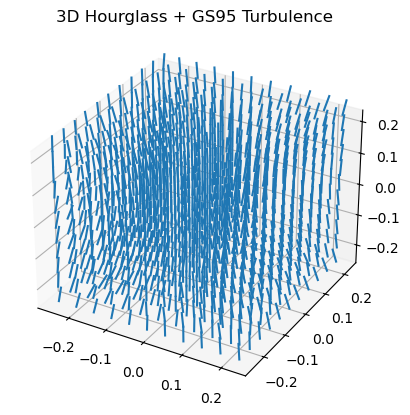

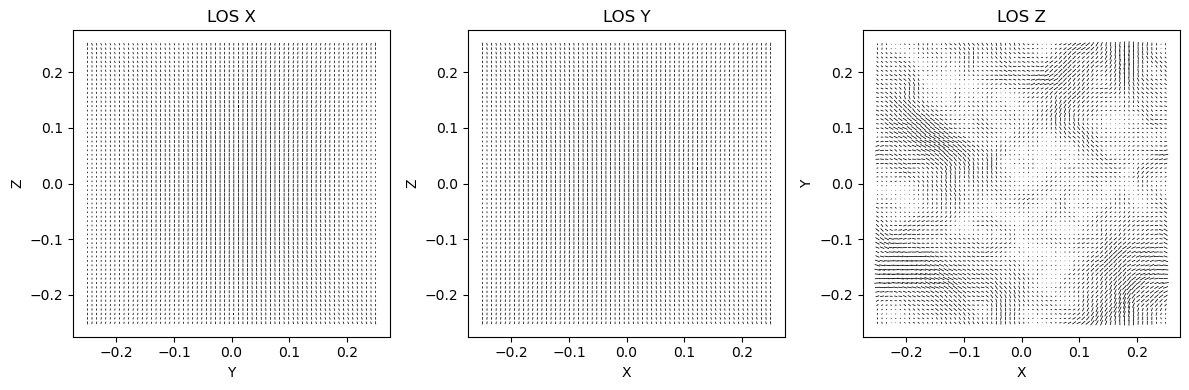

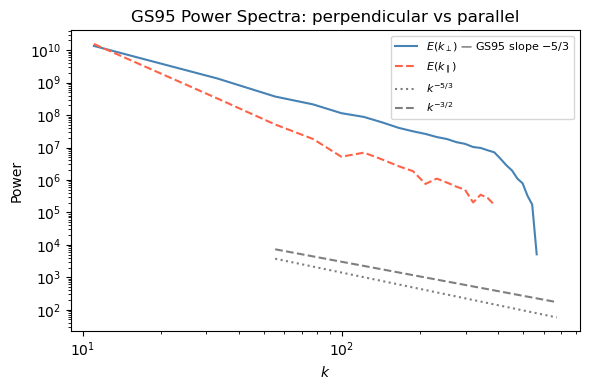

Mean polarization fraction: 0.8238
Mean depolarization cos²γ:  0.0206


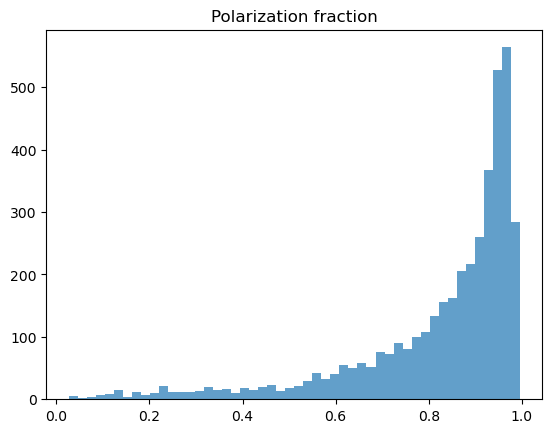

In [10]:
def _gs95_turbulence(X, Y, Z, Bx0, By0, Bz0, M_A,
                     alfven_fraction=0.6,
                     slow_fraction=0.2,
                     fast_fraction=0.2,
                     anisotropy_strength=1.0,
                     seed=None):


    assert abs(alfven_fraction + slow_fraction + fast_fraction - 1.0) < 1e-9, \
        "Mode fractions must sum to 1."

    g_size = X.shape[0]
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------------
    # 1.  Mean field direction  (volume-averaged background field)
    #     Used as the reference axis for computing k_∥ and k_⊥.
    #     For a smoothly varying hourglass field this is a good global-
    #     frame approximation; for strongly tangled fields one would need
    #     to work mode-by-mode in a local frame.
    # ------------------------------------------------------------------
    B0_mean = np.array([Bx0.mean(), By0.mean(), Bz0.mean()])
    B0_mag  = np.linalg.norm(B0_mean)
    if B0_mag < 1e-12:          # degenerate: fall back to z-axis
        b_hat = np.array([0., 0., 1.])
    else:
        b_hat = B0_mean / B0_mag

    # ------------------------------------------------------------------
    # 2.  Fourier k-grid
    # ------------------------------------------------------------------
    dx = X[1, 0, 0] - X[0, 0, 0]   # uniform spacing assumed
    kx = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    k2   = KX**2 + KY**2 + KZ**2
    k    = np.sqrt(k2)
    k2_s = np.where(k2 > 0, k2, 1.0)   # safe denominator

    # ------------------------------------------------------------------
    # 3.  k_∥  and  k_⊥  relative to mean field direction
    # ------------------------------------------------------------------
    # k_∥ = k · b_hat
    k_par = KX * b_hat[0] + KY * b_hat[1] + KZ * b_hat[2]

    # k_⊥ = sqrt(k² - k_∥²)
    k_perp2 = np.maximum(k2 - k_par**2, 0.0)
    k_perp  = np.sqrt(k_perp2)

    # ------------------------------------------------------------------
    # 4.  GS95 spectral weight for Alfvén / slow modes
    #
    #     W_AS(k) = k_perp^{-11/6}
    #               × exp( -anisotropy_strength × (k_∥ / k_perp^{2/3})² )
    #
    #     The Gaussian factor enforces critical balance  k_∥ ~ k_perp^{2/3},
    #     suppressing modes with  k_∥ ≫ k_perp^{2/3}  (non-resonant eddies).
    #     At anisotropy_strength=0 this reduces to pure Kolmogorov k^{-11/6}.
    # ------------------------------------------------------------------
    with np.errstate(divide="ignore", invalid="ignore"):
        # perpendicular spectral slope
        W_perp = np.where(k_perp > 0, k_perp ** (-11.0 / 6.0), 0.0)

        # critical-balance Gaussian envelope
        k_perp_cb = np.where(k_perp > 0, k_perp ** (2.0 / 3.0), 1.0)
        cb_arg    = np.where(k_perp > 0,
                             (k_par / k_perp_cb) ** 2 * anisotropy_strength,
                             0.0)
        W_AS = W_perp * np.exp(-cb_arg)

        # ------------------------------------------------------------------
        # 5.  Spectral weight for fast modes  (isotropic, k^{-3/2})
        # ------------------------------------------------------------------
        W_fast = np.where(k > 0, k ** (-9.0 / 4.0), 0.0)
        # Note: 3D power spectrum P(k) ~ k^α means E(k) ~ k^{α+2}.
        # For fast modes E(k) ~ k^{-3/2}  →  P(k) ~ k^{-3/2-2} = k^{-7/2}
        # Amplitude spectrum |δB(k)| ~ k^{-7/4}, so weight ~ k^{-7/4}.
        # We use k^{-9/4} for the field amplitude (= sqrt of power).
        # Adjust as needed for your normalisation convention.

    # ------------------------------------------------------------------
    # 6.  Generate random complex Fourier amplitudes
    # ------------------------------------------------------------------
    def rand_c(shape):
        return (rng.standard_normal(shape) +
                1j * rng.standard_normal(shape)) / np.sqrt(2)

    # --- Alfvén + slow modes  (share GS95 anisotropic spectrum) ---
    Fx_AS = rand_c(KX.shape) * W_AS
    Fy_AS = rand_c(KX.shape) * W_AS
    Fz_AS = rand_c(KX.shape) * W_AS

    # Project to purely transverse (solenoidal) modes:
    # Remove longitudinal component  ∇·δB = 0
    kdotF_AS   = KX * Fx_AS + KY * Fy_AS + KZ * Fz_AS
    Fx_AS -= KX * kdotF_AS / k2_s
    Fy_AS -= KY * kdotF_AS / k2_s
    Fz_AS -= KZ * kdotF_AS / k2_s

    # For Alfvén modes specifically: further project onto the plane
    # perpendicular to BOTH k and b_hat  (strict Alfvén polarisation).
    # Here we keep the simpler full-transverse projection for the
    # combined AS field; separating true Alfvén from slow requires
    # full MHD eigenvector decomposition and is left as an extension.

    # --- Fast modes  (isotropic, longitudinal-like compressive component) ---
    # Fast modes in MHD are compressible; their δB component is perpendicular
    # to b_hat but not necessarily to k.  We model them as a separate
    # isotropic solenoidal field here (simplest divergence-free treatment).
    Fx_f = rand_c(KX.shape) * W_fast
    Fy_f = rand_c(KX.shape) * W_fast
    Fz_f = rand_c(KX.shape) * W_fast

    kdotF_f   = KX * Fx_f + KY * Fy_f + KZ * Fz_f
    Fx_f -= KX * kdotF_f / k2_s
    Fy_f -= KY * kdotF_f / k2_s
    Fz_f -= KZ * kdotF_f / k2_s

    # ------------------------------------------------------------------
    # 7.  Transform to real space
    # ------------------------------------------------------------------
    dBx_AS = np.fft.ifftn(Fx_AS).real
    dBy_AS = np.fft.ifftn(Fy_AS).real
    dBz_AS = np.fft.ifftn(Fz_AS).real

    dBx_f  = np.fft.ifftn(Fx_f).real
    dBy_f  = np.fft.ifftn(Fy_f).real
    dBz_f  = np.fft.ifftn(Fz_f).real

    # ------------------------------------------------------------------
    # 8.  Normalise each mode to its prescribed energy fraction,
    #     then combine and normalise total RMS to M_A
    # ------------------------------------------------------------------
    def rms3(bx, by, bz):
        return np.sqrt(np.mean(bx**2 + by**2 + bz**2))

    rms_AS = rms3(dBx_AS, dBy_AS, dBz_AS)
    rms_f  = rms3(dBx_f,  dBy_f,  dBz_f)

    af = np.sqrt(alfven_fraction + slow_fraction)   # combined AS fraction
    ff = np.sqrt(fast_fraction)

    if rms_AS > 0:
        dBx_AS *= af / rms_AS
        dBy_AS *= af / rms_AS
        dBz_AS *= af / rms_AS

    if rms_f > 0:
        dBx_f  *= ff / rms_f
        dBy_f  *= ff / rms_f
        dBz_f  *= ff / rms_f

    # Combined turbulent field
    dBx = dBx_AS + dBx_f
    dBy = dBy_AS + dBy_f
    dBz = dBz_AS + dBz_f

    # Normalise total RMS to M_A (so M_A = <|δB|²>^{1/2} / <|B0|²>^{1/2})
    rms_tot = rms3(dBx, dBy, dBz)
    if rms_tot > 0:
        scale = M_A * B0_mag / rms_tot
        dBx *= scale
        dBy *= scale
        dBz *= scale

    return dBx, dBy, dBz


# =============================================================================
#  MAIN FUNCTION  —  same signature as hourglass_field_kolmo
# =============================================================================

def hourglass_field_gs95(M_A, g_size, iaxis, plotting,
                         alfven_fraction=0.6,
                         slow_fraction=0.2,
                         fast_fraction=0.2,
                         anisotropy_strength=1.0,
                         seed=None):

    # -------------------------------------------------------------------------
    # PARAMETERS  (unchanged from Kolmogorov version)
    # -------------------------------------------------------------------------
    R_outer  = 5.0
    h        = 1.0
    B0       = 1.0
    Bm       = 1.0
    betam    = Bm / B0
    N_terms  = 3
    I0       = 1.0

    rho      = 1.0
    sigma_v  = 1.0
    cf_prefactor = np.sqrt(4 * np.pi * rho) * sigma_v

    # -------------------------------------------------------------------------
    # CARTESIAN GRID
    # -------------------------------------------------------------------------
    x = np.linspace(-0.25, 0.25, g_size)
    y = np.linspace(-0.25, 0.25, g_size)
    z = np.linspace(-0.25, 0.25, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    R      = np.sqrt(X**2 + Y**2)
    R_safe = np.where(R == 0, 1e-12, R)

    # -------------------------------------------------------------------------
    # BESSEL SERIES HOURGLASS FIELD  (unchanged)
    # -------------------------------------------------------------------------
    roots   = jn_zeros(1, N_terms)
    weights = 2 / (roots * j0(roots)**2)
    eta     = h / R_outer

    Br0 = np.zeros_like(R)
    Bz0 = np.zeros_like(R)

    for n in range(N_terms):
        lam   = roots[n]
        w     = weights[n]

        J0_eval = j0(lam * R)
        J1_eval = j1(lam * R)

        arg_neg = lam * eta / 2 - Z / eta
        arg_pos = lam * eta / 2 + Z / eta

        er_neg  = erfc(arg_neg)
        er_pos  = erfc(arg_pos)

        exp_neg = np.exp(-lam * Z)
        exp_pos = np.exp( lam * Z)

        brackets0 = er_pos * exp_pos + er_neg * exp_neg
        brackets1 = er_neg * exp_neg - er_pos * exp_pos

        Br0 += w * J1_eval * betam * brackets1
        Bz0 += w * J0_eval * betam * brackets0

    Bz0 += 1.0

    Bx0 = Br0 * (X / R_safe)
    By0 = Br0 * (Y / R_safe)

    # -------------------------------------------------------------------------
    # GS95 ANISOTROPIC TURBULENCE  (replaces Kolmogorov block)
    # -------------------------------------------------------------------------
    dBx, dBy, dBz = _gs95_turbulence(
        X, Y, Z, Bx0, By0, Bz0, M_A,
        alfven_fraction=alfven_fraction,
        slow_fraction=slow_fraction,
        fast_fraction=fast_fraction,
        anisotropy_strength=anisotropy_strength,
        seed=seed
    )

    # -------------------------------------------------------------------------
    # ADD TURBULENCE TO BACKGROUND FIELD
    # -------------------------------------------------------------------------
    Bx = Bx0 + dBx
    By = By0 + dBy
    Bz = Bz0 + dBz

    # -------------------------------------------------------------------------
    # ENFORCE ∇·B = 0 ON TOTAL FIELD
    # -------------------------------------------------------------------------
    kx = np.fft.fftfreq(g_size, d=x[1]-x[0]) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=y[1]-y[0]) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=z[1]-z[0]) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    k2 = KX**2 + KY**2 + KZ**2
    k    = np.sqrt(k2)
    
    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_k + KY * By_k + KZ * Bz_k
    mask    = k2 > 0
    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real

    # -------------------------------------------------------------------------
    # STOKES PARAMETERS  (unchanged)
    # -------------------------------------------------------------------------
    if iaxis == 0:
        B_los     = Bx
        B1, B2    = By, Bz
    elif iaxis == 1:
        B_los     = By
        B1, B2    = Bx, Bz
    else:
        B_los     = Bz
        B1, B2    = Bx, By

    B_los2  = B_los**2
    B_perp2 = B1**2 + B2**2
    Btot2   = B_perp2 + B_los2

    cos2g   = B_perp2 / (Btot2 + 1e-12)
    I_local = I0 * cos2g

    mask_q  = B_perp2 > 1e-12
    Q = np.zeros_like(B1)
    U = np.zeros_like(B1)
    Q[mask_q] = I_local[mask_q] * (B2[mask_q]**2 - B1[mask_q]**2) / B_perp2[mask_q]
    U[mask_q] = I_local[mask_q] * (2 * B1[mask_q] * B2[mask_q])   / B_perp2[mask_q]

    I_obs   = I_local.sum(axis=iaxis)
    Q_obs   = Q.sum(axis=iaxis)
    U_obs   = U.sum(axis=iaxis)

    P_obs   = np.sqrt(Q_obs**2 + U_obs**2) / (I_obs + 1e-12)
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)

    # -------------------------------------------------------------------------
    # DIAGNOSTIC: anisotropy ratio  (should differ from Kolmogorov run)
    # -------------------------------------------------------------------------
    # Measure power in k_∥ vs k_⊥ slabs to confirm anisotropy was injected
    B0_mean = np.array([Bx0.mean(), By0.mean(), Bz0.mean()])
    B0_mag  = np.linalg.norm(B0_mean)
    b_hat   = B0_mean / B0_mag if B0_mag > 1e-12 else np.array([0., 0., 1.])

    k_par  = KX * b_hat[0] + KY * b_hat[1] + KZ * b_hat[2]
    k_perp = np.sqrt(np.maximum(k2 - k_par**2, 0.0))

    dBx_k = np.fft.fftn(dBx)
    dBy_k = np.fft.fftn(dBy)
    dBz_k = np.fft.fftn(dBz)
    power  = (np.abs(dBx_k)**2 + np.abs(dBy_k)**2 + np.abs(dBz_k)**2)

    # Correlation length ratio: Λ_∥ / Λ_⊥  (>1 means elongated along B → GS95)
    par_scale  = np.sum(power / (np.abs(k_par)  + 1e-12))
    perp_scale = np.sum(power / (np.abs(k_perp) + 1e-12))
    aniso_ratio = par_scale / perp_scale
    print(f"[GS95] Anisotropy ratio Λ∥/Λ⊥ = {aniso_ratio:.3f}  "
          f"(>1 → field-aligned eddies as expected)")

    # -------------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------------
    if plotting:
        skip = max(1, g_size // 10)

        # 3-D overview
        fig = plt.figure()
        ax  = fig.add_subplot(111, projection='3d')
        ax.quiver(
            X[::skip, ::skip, ::skip],
            Y[::skip, ::skip, ::skip],
            Z[::skip, ::skip, ::skip],
            Bx[::skip, ::skip, ::skip],
            By[::skip, ::skip, ::skip],
            Bz[::skip, ::skip, ::skip],
            length=0.05, normalize=True, linewidth=1.5, arrow_length_ratio=0)
        ax.set_title("3D Hourglass + GS95 Turbulence")
        plt.show()

        mid = g_size // 2

        # 2-D field slices
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].quiver(Y[mid, :, :], Z[mid, :, :],
                       By[mid, :, :], Bz[mid, :, :],
                       headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[0].set_xlabel("Y"); axes[0].set_ylabel("Z"); axes[0].set_title("LOS X")

        axes[1].quiver(X[:, mid, :], Z[:, mid, :],
                       Bx[:, mid, :], Bz[:, mid, :],
                       headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[1].set_xlabel("X"); axes[1].set_ylabel("Z"); axes[1].set_title("LOS Y")

        axes[2].quiver(X[:, :, mid], Y[:, :, mid],
                       Bx[:, :, mid], By[:, :, mid],
                       headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[2].set_xlabel("X"); axes[2].set_ylabel("Y"); axes[2].set_title("LOS Z")

        plt.tight_layout()
        plt.show()

        # Power spectra comparison
        k_bins   = np.linspace(0, k.max(), g_size // 2)
        k_mid    = 0.5 * (k_bins[:-1] + k_bins[1:])

        E_perp   = np.zeros(len(k_mid))
        E_par    = np.zeros(len(k_mid))

        for i, (k0, k1) in enumerate(zip(k_bins[:-1], k_bins[1:])):
            m_perp = (k_perp >= k0) & (k_perp < k1)
            m_par  = (np.abs(k_par) >= k0) & (np.abs(k_par) < k1)
            E_perp[i] = power[m_perp].sum() if m_perp.any() else 0
            E_par[i]  = power[m_par ].sum() if m_par.any()  else 0

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.loglog(k_mid[E_perp > 0], E_perp[E_perp > 0],
                  label=r'$E(k_\perp)$ — GS95 slope $-5/3$', color='steelblue')
        ax.loglog(k_mid[E_par > 0],  E_par[E_par > 0],
                  label=r'$E(k_\parallel)$', color='tomato', linestyle='--')

        # Reference slopes
        k_ref  = k_mid[k_mid > k_mid[1]]
        ax.loglog(k_ref, 3e6 * k_ref**(-5/3), 'k:',  alpha=0.5, label=r'$k^{-5/3}$')
        ax.loglog(k_ref, 3e6 * k_ref**(-3/2), 'k--', alpha=0.5, label=r'$k^{-3/2}$')
        ax.set_xlabel(r'$k$'); ax.set_ylabel(r'Power')
        ax.set_title('GS95 Power Spectra: perpendicular vs parallel')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    return P_obs, phi_obs, cos2g.mean(axis=iaxis)


# =============================================================================
#  QUICK COMPARISON HELPER
# =============================================================================

def compare_kolmo_vs_gs95(M_A=0.5, g_size=64, iaxis=2):

    print("Running Kolmogorov model...")
    P_k, phi_k, cg_k = hourglass_field_kolmo(M_A, g_size, iaxis, plotting=False)

    print("Running GS95 model...")
    P_g, phi_g, cg_g = hourglass_field_gs95(M_A, g_size, iaxis, plotting=False,
                                             anisotropy_strength=1.0, seed=42)

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    fig.suptitle(f"Kolmogorov vs GS95  |  M_A = {M_A}  |  LOS axis = {iaxis}")

    im0 = axes[0, 0].imshow(P_k, origin='lower', cmap='inferno')
    axes[0, 0].set_title("Kolmogorov — Polarisation fraction P")
    plt.colorbar(im0, ax=axes[0, 0])

    im1 = axes[0, 1].imshow(P_g, origin='lower', cmap='inferno')
    axes[0, 1].set_title("GS95 — Polarisation fraction P")
    plt.colorbar(im1, ax=axes[0, 1])

    im2 = axes[1, 0].imshow(phi_k, origin='lower', cmap='RdBu', vmin=-np.pi/2, vmax=np.pi/2)
    axes[1, 0].set_title("Kolmogorov — PA φ [rad]")
    plt.colorbar(im2, ax=axes[1, 0])

    im3 = axes[1, 1].imshow(phi_g, origin='lower', cmap='RdBu', vmin=-np.pi/2, vmax=np.pi/2)
    axes[1, 1].set_title("GS95 — PA φ [rad]")
    plt.colorbar(im3, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

    print(f"\n  Mean P  :  Kolmogorov = {P_k.mean():.4f}   GS95 = {P_g.mean():.4f}")
    print(f"  Std  P  :  Kolmogorov = {P_k.std():.4f}    GS95 = {P_g.std():.4f}")
    print(f"  Mean cg :  Kolmogorov = {cg_k.mean():.4f}   GS95 = {cg_g.mean():.4f}")


# =============================================================================
#  MAIN
# =============================================================================
if __name__ == "__main__":
    P, phi, cg = hourglass_field_gs95(
        M_A=0.1,
        g_size=64,
        iaxis=2,
        plotting=True,
        alfven_fraction=0.6,
        slow_fraction=0.2,
        fast_fraction=0.2,
        anisotropy_strength=1.0,
        seed=42
    )
    print(f"Mean polarization fraction: {P.mean():.4f}")
    print(f"Mean depolarization cos²γ:  {cg.mean():.4f}")

    plt.hist(P.flatten(), bins=50, alpha=0.7)
    plt.title('Polarization fraction')
    